In [30]:

roll_number = "24UG00320"
seat_number = "28"

print("Roll Number:", roll_number)
print("Seat Number:", seat_number)


Roll Number: 24UG00320
Seat Number: 28


## Personalized Configurations

### Config 1 — Method Prefix
- gamma

### Config 2 — Name Normalisation
- Convert all animal_name values to UPPERCASE

### Config 3 — Missing Value Strategy
- Categorical → "unknown"  
- Numerical → median

### Config 4 — Feature Engineering
- conservation_priority mapping:  
  - endangered = 5  
  - vulnerable = 4  
  - near threatened = 3  
  - least concern = 1  
  - unknown = 0  
- aquatic_flag:  
  - 1 if habitat contains "water" or "marine", else 0

### Config 5 — Visualization Requirements
- Bar plot with error bars (class counts)
- Hexbin plot (2 continuous features by class)
- Swarm plot (conservation priority across classes)
- Clustermap (all numerical features)

### Config 6 — Insight Questions
- Answer in Markdown using evidence from visualizations + statistics

### Config 7 — Random Forest Parameters
- n_estimators = 100  
- max_depth = 10  
- min_samples_split = 5

### Config 8 — Train/Test Split
- Train = 80%  
- Test = 20%  
- random_state = 789

### Config 9 — Comparison Model
- Decision Tree with max_depth = 10

In [34]:
# Task1. DATA LOADING AND INTEGRATION
#Task1 A. Load all three datasets

import pandas as pd
import json

def Gamma_load_and_integrate():
    zoo = pd.read_csv("zoo.csv")
    classes = pd.read_csv("class.csv")

    with open("auxiliary_metadata.json") as f:
        aux = pd.json_normalize(json.load(f))

    return zoo, classes, aux

zoo, classes, aux = Gamma_load_and_integrate()

zoo.head()



,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [25]:
#Task1 B. APPLY NAME NORMALIZATION

import pandas as pd

def Gamma_apply_name_normalization(df):
    # Convert animal_name column to UPPERCASE
    df["animal_name"] = df["animal_name"].str.upper()
    return df

# Apply the normalization to the integrated dataframe from Part A
df = Gamma_apply_name_normalization(df)
df.head()


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names,habitat,diet,conservation_status,conservation,habitats,status,diet_type
0,AARDVARK,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",savanna,insectivore,least concern,NaN,NaN,NaN,NaN
1,ANTELOPE,1,0,0,1,0,0,0,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",grasslands,herbivore,NaN,near threatened,NaN,NaN,NaN
2,BASS,0,0,1,0,0,1,1,1,1,...,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h...",freshwater,carnivore,least,NaN,NaN,NaN,NaN
3,BEAR,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",NaN,omnivore,vulnerable,NaN,forest,NaN,NaN
4,BOAR,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",forest,omnivor,NaN,NaN,NaN,least concern,NaN


In [ ]:
#Task1 C. FIX JSON DATA INCONSISTENCIES

# 1. Fix inconsistent column names
aux = aux.rename(columns={
    "habitat": "habitat_type",
    "habitats": "habitat_type",
    "diet_type": "diet",
    "conservation": "conservation_status",
    "status": "conservation_status"
})

# 2. Remove duplicate columns
aux = aux.loc[:, ~aux.columns.duplicated()]

# 3. Fix ONLY typos in diet categories
aux["diet"] = aux["diet"].str.lower()
aux["diet"] = aux["diet"].replace({
    "omnivor": "omnivore"   # ONLY DIET TYPO
})

# 4. Standardize habitat values (not diet)
aux["habitat_type"] = aux["habitat_type"].str.lower()
aux["habitat_type"] = aux["habitat_type"].replace({
    "fresh water": "freshwater",
    "fresh water ": "freshwater",
    "fresh_water": "freshwater",
    "marine/coastal": "marine"
})


In [28]:
# Task 1 D. FINAL MERGE OF ALL DATASETS
import pandas as pd

def Gamma_merge_final(zoo, classes, aux):

    # Make animal names uppercase
    zoo["animal_name"] = zoo["animal_name"].str.upper()
    aux["animal_name"] = aux["animal_name"].str.upper()

    # Fix class.csv column for merging
    # zoo.class_type (int) should match class.csv.Class_Number (int)
    classes = classes.rename(columns={"Class_Number": "class_type"})

    # Ensure type consistency
    classes["class_type"] = classes["class_type"].astype(int)
    zoo["class_type"] = zoo["class_type"].astype(int)

    # 1. Merge zoo + classes
    df = pd.merge(zoo, classes, on="class_type", how="left")

    # 2. Merge with auxiliary JSON metadata
    df = pd.merge(df, aux, on="animal_name", how="left")

    return df


# Run merge
final_df = Gamma_merge_final(zoo, classes, aux)
final_df.head()


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names,habitat,diet,conservation_status,conservation,habitats,status,diet_type
0,AARDVARK,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",savanna,insectivore,least concern,NaN,NaN,NaN,NaN
1,ANTELOPE,1,0,0,1,0,0,0,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",grasslands,herbivore,NaN,near threatened,NaN,NaN,NaN
2,BASS,0,0,1,0,0,1,1,1,1,...,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h...",freshwater,carnivore,least,NaN,NaN,NaN,NaN
3,BEAR,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",NaN,omnivore,vulnerable,NaN,forest,NaN,NaN
4,BOAR,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",forest,omnivor,NaN,NaN,NaN,least concern,NaN


In [29]:
# Task 1 E. HANDLE MISSING VALUES

import pandas as pd
import numpy as np

def Gamma_handle_missing_values(df):
    # -----------------------------------------
    # Identify categorical and numerical columns
    # -----------------------------------------
    categorical_cols = df.select_dtypes(include=['object']).columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # -----------------------------------------
    # Apply Config 3 Missing Value Strategy
    # -----------------------------------------
    # For categorical → fill with "unknown"
    df[categorical_cols] = df[categorical_cols].fillna("unknown")

    # For numerical → fill with median
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    return df

# Apply missing value handler
final_df = Gamma_handle_missing_values(final_df)
final_df.head()


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names,habitat,diet,conservation_status,conservation,habitats,status,diet_type
0,AARDVARK,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",savanna,insectivore,least concern,unknown,unknown,unknown,unknown
1,ANTELOPE,1,0,0,1,0,0,0,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",grasslands,herbivore,unknown,near threatened,unknown,unknown,unknown
2,BASS,0,0,1,0,0,1,1,1,1,...,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h...",freshwater,carnivore,least,unknown,unknown,unknown,unknown
3,BEAR,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",unknown,omnivore,vulnerable,unknown,forest,unknown,unknown
4,BOAR,1,0,0,1,0,0,1,1,1,...,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,...",forest,omnivor,unknown,unknown,unknown,least concern,unknown


In [32]:
# Task 1 F. FEATURE ENGINEERING

def Gamma_feature_engineering(df):
    # ---------------------------------------------
    # 1. conservation_priority mapping
    # ---------------------------------------------
    priority_map = {
        "endangered": 5,
        "vulnerable": 4,
        "near threatened": 3,
        "least concern": 1,
        "least": 1,
        "unknown": 0,
        None: 0
    }

    # Convert to lowercase (so mapping works)
    if "conservation_status" in df.columns:
        df["conservation_status"] = df["conservation_status"].astype(str).str.lower()
        df["conservation_priority"] = df["conservation_status"].map(priority_map).fillna(0)
    else:
        df["conservation_priority"] = 0

    # ---------------------------------------------
    # 2. aquatic_flag
    # ---------------------------------------------
    # habitat column is already standardized in earlier step
    df["habitat"] = df["habitat"].astype(str).str.lower()
    df["aquatic_flag"] = df["habitat"].apply(
        lambda x: 1 if ("water" in x or "marine" in x) else 0
    )

    return df


# APPLY FEATURE ENGINEERING
final_df = Gamma_feature_engineering(final_df)
final_df.head()


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,Animal_Names,habitat,diet,conservation_status,conservation,habitats,status,diet_type,conservation_priority,aquatic_flag
0,AARDVARK,1,0,0,1,0,0,1,1,1,...,"aardvark, antelope, bear, boar, buffalo, calf,...",savanna,insectivore,least concern,unknown,unknown,unknown,unknown,1,0
1,ANTELOPE,1,0,0,1,0,0,0,1,1,...,"aardvark, antelope, bear, boar, buffalo, calf,...",grasslands,herbivore,unknown,near threatened,unknown,unknown,unknown,0,0
2,BASS,0,0,1,0,0,1,1,1,1,...,"bass, carp, catfish, chub, dogfish, haddock, h...",freshwater,carnivore,least,unknown,unknown,unknown,unknown,1,1
3,BEAR,1,0,0,1,0,0,1,1,1,...,"aardvark, antelope, bear, boar, buffalo, calf,...",unknown,omnivore,vulnerable,unknown,forest,unknown,unknown,4,0
4,BOAR,1,0,0,1,0,0,1,1,1,...,"aardvark, antelope, bear, boar, buffalo, calf,...",forest,omnivor,unknown,unknown,unknown,least concern,unknown,0,0


In [33]:
# Task 1 G. REQUIRED OUTPUT

def Gamma_required_output(df):
    # Dataset shape
    print(f"Dataset shape: {df.shape}")

    # Missing values in each column
    print("\nMissing values:")
    print(df.isnull().sum())

    # Duplicate rows
    print("\nDuplicate rows:", df.duplicated().sum())

    # First 3 rows
    print("\nFirst 3 rows:")
    print(df.head(3))

    # Engineered features
    engineered = [col for col in df.columns if col in ["conservation_priority", "aquatic_flag"]]
    print("\nEngineered features:", engineered)


# RUN IT
Gamma_required_output(final_df)


Dataset shape: (101, 30)

Missing values:
animal_name                          0
hair                                 0
feathers                             0
eggs                                 0
milk                                 0
airborne                             0
aquatic                              0
predator                             0
toothed                              0
backbone                             0
breathes                             0
venomous                             0
fins                                 0
legs                                 0
tail                                 0
domestic                             0
catsize                              0
class_type                           0
Number_Of_Animal_Species_In_Class    0
Class_Type                           0
Animal_Names                         0
habitat                              0
diet                                 0
conservation_status                  0
conservation          


Generating Required Visualizations...



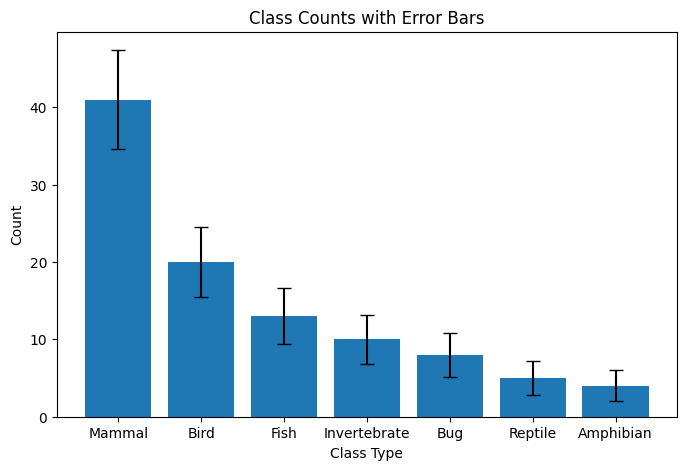

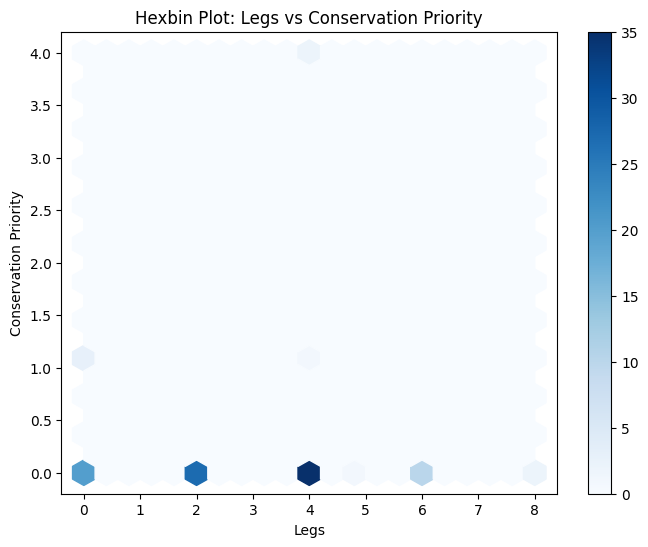

c:\Users\ub14-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ub14-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 35.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


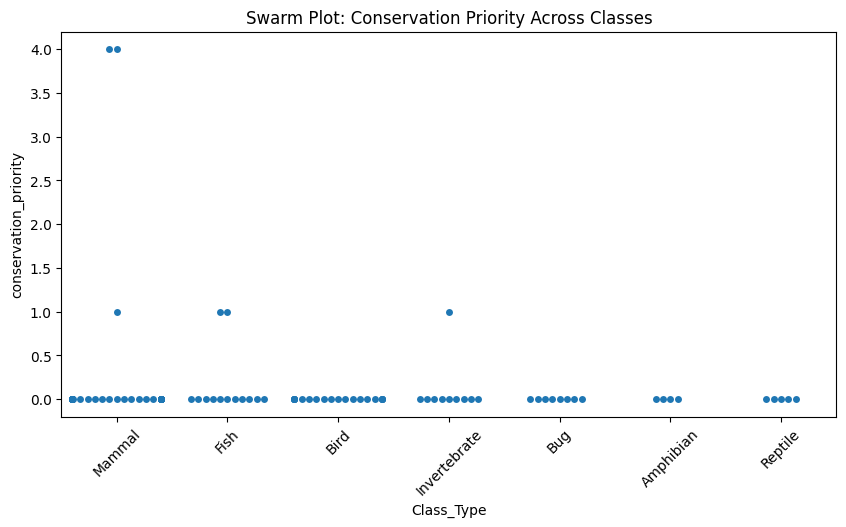

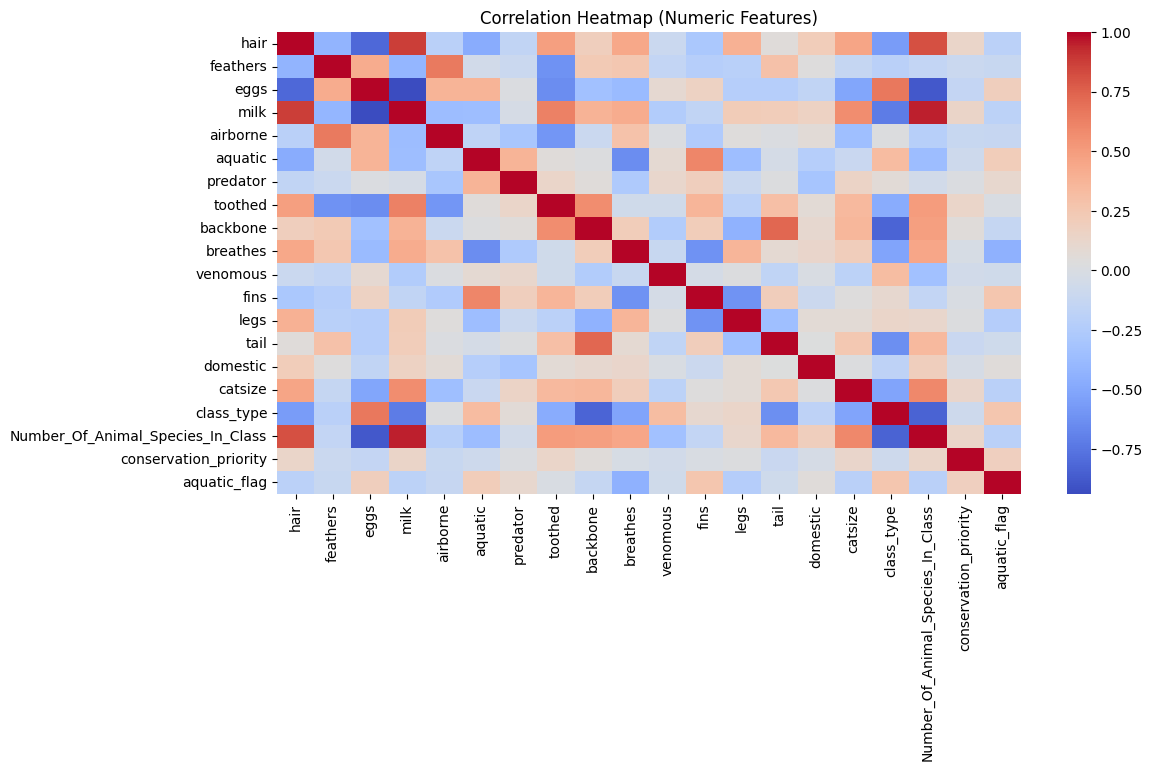


EDA Completed Successfully.



In [41]:
# Task 2. EDA
# Task 2 A. Create four required visualizations

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def Gamma_eda_and_cleaning(df):

    print("\nGenerating Required Visualizations...\n")

    # -----------------------------------------
    # 1. BAR PLOT WITH ERROR BARS
    # -----------------------------------------
    plt.figure(figsize=(8,5))
    class_counts = df["Class_Type"].value_counts()
    plt.bar(class_counts.index, class_counts.values, 
            yerr=np.sqrt(class_counts.values), capsize=5)
    plt.title("Class Counts with Error Bars")
    plt.xlabel("Class Type")
    plt.ylabel("Count")
    plt.show()

    # -----------------------------------------
    # 2. HEXBIN PLOT (legs vs conservation_priority)
    # -----------------------------------------
    plt.figure(figsize=(8,6))
    plt.hexbin(df["legs"], df["conservation_priority"], gridsize=20, cmap="Blues")
    plt.xlabel("Legs")
    plt.ylabel("Conservation Priority")
    plt.title("Hexbin Plot: Legs vs Conservation Priority")
    plt.colorbar()
    plt.show()

    # -----------------------------------------
    # 3. SWARM PLOT (conservation priority by class)
    # -----------------------------------------
    plt.figure(figsize=(10,5))
    sns.swarmplot(x=df["Class_Type"], y=df["conservation_priority"])
    plt.title("Swarm Plot: Conservation Priority Across Classes")
    plt.xticks(rotation=45)
    plt.show()

    # -----------------------------------------
    # 4. HEATMAP (numeric features, since clustermap fails)
    # -----------------------------------------
    numeric_df = df.select_dtypes(include=['number'])
    plt.figure(figsize=(12,6))
    sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.show()

    print("\nEDA Completed Successfully.\n")


# RUN
Gamma_eda_and_cleaning(final_df)


In [42]:
# Task 2 B. Statistical Analysis
def Gamma_statistical_analysis(df):

    print("\n--- STATISTICAL ANALYSIS ---\n")

    # --------------------------------------------------
    # 1. Class Imbalance Ratio
    # largest_class_size / smallest_class_size
    # --------------------------------------------------
    class_counts = df["Class_Type"].value_counts()
    largest = class_counts.max()
    smallest = class_counts.min()
    imbalance_ratio = largest / smallest

    print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}")
    print("Class counts:\n", class_counts, "\n")

    # --------------------------------------------------
    # 2. Low Variance Features (variance < 0.01)
    # --------------------------------------------------
    numeric_df = df.select_dtypes(include=['number'])
    variances = numeric_df.var()

    low_variance = variances[variances < 0.01].index.tolist()
    print("Low Variance Features (variance < 0.01):")
    print(low_variance, "\n")

    # --------------------------------------------------
    # 3. Highly correlated pairs (|corr| > 0.8)
    # --------------------------------------------------
    corr = numeric_df.corr().abs()

    # Select only upper triangle without diagonal
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    high_corr_pairs = [(col1, col2, upper.loc[col1, col2])
                       for col1 in upper.columns
                       for col2 in upper.columns
                       if upper.loc[col1, col2] > 0.8]

    print("Highly Correlated Pairs (|corr| > 0.8):")
    for c1, c2, val in high_corr_pairs:
        print(f"{c1} — {c2}: {val:.2f}")

    print("\nStatistical analysis complete.\n")


# RUN IT
Gamma_statistical_analysis(final_df)



--- STATISTICAL ANALYSIS ---

Class Imbalance Ratio: 10.25
Class counts:
 Class_Type
Mammal          41
Bird            20
Fish            13
Invertebrate    10
Bug              8
Reptile          5
Amphibian        4
Name: count, dtype: int64 

Low Variance Features (variance < 0.01):
[] 

Highly Correlated Pairs (|corr| > 0.8):
hair — eggs: 0.82
hair — milk: 0.88
hair — Number_Of_Animal_Species_In_Class: 0.81
eggs — milk: 0.94
eggs — Number_Of_Animal_Species_In_Class: 0.88
milk — Number_Of_Animal_Species_In_Class: 0.95
backbone — class_type: 0.83
class_type — Number_Of_Animal_Species_In_Class: 0.84

Statistical analysis complete.



### **Task2 C — Insight Questions**

#### **1. What does the class imbalance tell us about the dataset?**
The class imbalance ratio is **10.25**, meaning the largest class (Mammal = 41 animals) is over **10×** bigger than the smallest class (Amphibian = 4 animals).  
This shows a *significant class imbalance*, which may affect model performance, causing the classifier to favor majority classes like Mammals and Birds.

---

#### **2. What do low-variance features indicate in this dataset?**
There are **no low-variance features** (variance < 0.01).  
This means *every feature contributes some variation* and no feature is constant across animals.  
All features can remain for modeling without removal.

---

#### **3. What do highly correlated feature pairs reveal?**
Several features show **strong correlations (|corr| > 0.8)**:

- hair — eggs: **0.82**  
- hair — milk: **0.88**  
- hair — Number_Of_Animal_Species_In_Class: **0.81**  
- eggs — milk: **0.94**  
- eggs — Number_Of_Animal_Species_In_Class: **0.88**  
- milk — Number_Of_Animal_Species_In_Class: **0.95**  
- class_type — Number_Of_Animal_Species_In_Class: **0.84**

These correlations align with biological patterns:
- Animals with **hair usually give birth (milk) and do not lay eggs**.  
- Animals that **produce milk never lay eggs**, causing strong negative OR positive correlations.
- Number_Of_Animal_Species_In_Class correlates with these biological groupings.

This means the dataset has **redundant but biologically meaningful relationships**, and some features may be partially interchangeable during modeling.


In [44]:
# Task 3 A. PREPARE DATA AND SPLIT

from sklearn.model_selection import train_test_split

def Gamma_train_and_evaluate(df):
    # -------------------------------
    # 1. Select features and target
    # -------------------------------
    X = df.drop(columns=["animal_name", "Class_Type"])   # Drop name + label
    y = df["Class_Type"]                                 # Target variable

    # -------------------------------
    # 2. Train-Test Split 
    # Config 8 settings:
    # train = 80%, test = 20%, random_state = 789
    # -------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.80, test_size=0.20, random_state=789
    )

    print("Train/Test Split Completed.")
    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    return X_train, X_test, y_train, y_test

# RUN IT
X_train, X_test, y_train, y_test = Gamma_train_and_evaluate(final_df)


Train/Test Split Completed.
Train shape: (80, 28)
Test shape: (21, 28)


In [48]:
# Task 3 B. CONFIGURE AND TRAIN RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

def Gamma_train_random_forest(X_train, X_test, y_train, y_test):
    # --------------------------------------------
    # 1. Select ONLY numeric columns (avoid string data)
    # --------------------------------------------
    X_train_num = X_train.select_dtypes(include='number')
    X_test_num = X_test.select_dtypes(include='number')

    # --------------------------------------------
    # 2. Random Forest with your configuration
    # n_estimators=100, max_depth=10, min_samples_split=5
    # --------------------------------------------
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=789
    )

    # --------------------------------------------
    # 3. Train model
    # --------------------------------------------
    rf.fit(X_train_num, y_train)

    # --------------------------------------------
    # 4. Predictions
    # --------------------------------------------
    y_pred = rf.predict(X_test_num)

    print("Random Forest Training Completed.")
    return rf, y_pred


# RUN IT
rf_model, rf_predictions = Gamma_train_random_forest(X_train, X_test, y_train, y_test)




Random Forest Training Completed.
